Project root: /Users/syedadnanahmad/Downloads/AI_Tumour_detection
ORCHID root: /Users/syedadnanahmad/Downloads/AI_Tumour_detection/data/ORCHID
Total slides found: 448


,split,class,slide_id,slide_path,n_patches,patch_paths
0,train,mdoscc,o-3-00-01,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,77,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
1,train,mdoscc,o-3-00-02,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,71,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
2,train,mdoscc,o-3-00-03,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,73,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
3,train,mdoscc,o-3-00-04,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,71,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
4,train,mdoscc,o-3-00-05,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,72,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
5,train,mdoscc,o-3-00-06,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,35,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
6,train,mdoscc,o-3-00-07,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,42,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
7,train,mdoscc,o-3-00-08,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,76,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
8,train,mdoscc,o-3-00-09,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,78,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...
9,train,mdoscc,o-3-00-10,/Users/syedadnanahmad/Downloads/AI_Tumour_dete...,79,[/Users/syedadnanahmad/Downloads/AI_Tumour_det...



Slides per split:
split
test     150
train    149
val      149
dtype: int64

Slides per class (all splits):
class
wdoscc    132
mdoscc    124
osmf       93
pdoscc     57
normal     42
dtype: int64

Patch counts summary per class:


,count,sum,median,mean,min,max
class,,,,,,
wdoscc,132,4011,19.0,30.386364,1,233
mdoscc,124,3880,20.0,31.290323,1,126
osmf,93,3015,19.0,32.419355,3,114
pdoscc,57,2297,22.0,40.298246,11,145
normal,42,1502,23.5,35.761905,6,109



Example slide: o-3-00-01 class: mdoscc n_patches: 77


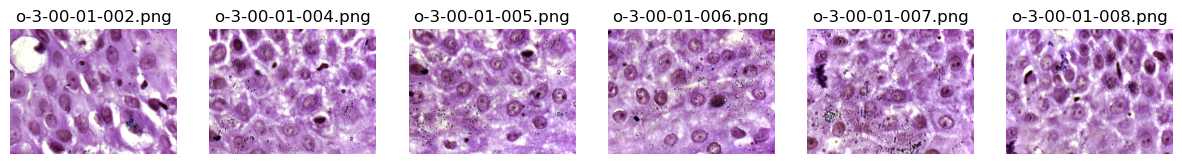

In [1]:
# Notebook cell: Inspect ORCHID dataset layout and build slide index
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = Path.home() / "Downloads" / "AI_Tumour_detection"      # run notebook with working dir = Oral_tumor_detection_and_subtyping
ORCHID_ROOT = PROJECT_ROOT / "data" / "ORCHID"

print("Project root:", PROJECT_ROOT)
print("ORCHID root:", ORCHID_ROOT)
assert ORCHID_ROOT.exists(), f"ORCHID folder not found at {ORCHID_ROOT}. Move your ORCHID folder there or change the path."

def build_slide_index(root_path):
    rows = []
    for split in ["train", "val", "test"]:
        split_path = Path(root_path) / split
        if not split_path.exists():
            print("Missing split:", split_path)
            continue
        for class_folder in sorted([x for x in split_path.iterdir() if x.is_dir()]):
            class_label = class_folder.name
            for slide_folder in sorted([s for s in class_folder.iterdir() if s.is_dir()]):
                # gather patches
                patch_paths = sorted([str(p) for p in slide_folder.iterdir() if p.suffix.lower() in (".png", ".jpg", ".jpeg")])
                if len(patch_paths) == 0:
                    continue
                rows.append({
                    "split": split,
                    "class": class_label,
                    "slide_id": slide_folder.name,
                    "slide_path": str(slide_folder),
                    "n_patches": len(patch_paths),
                    "patch_paths": patch_paths
                })
    df = pd.DataFrame(rows)
    return df

df_index = build_slide_index(ORCHID_ROOT)
print("Total slides found:", len(df_index))
display(df_index.head(10))

# Summary statistics
print("\nSlides per split:")
print(df_index.groupby("split").size())
print("\nSlides per class (all splits):")
print(df_index.groupby("class").size().sort_values(ascending=False))

print("\nPatch counts summary per class:")
display(df_index.groupby("class")["n_patches"].agg(["count", "sum", "median", "mean", "min", "max"]).sort_values("sum", ascending=False))

# Visual sanity check - show first 6 patches of first slide found
if len(df_index)>0:
    first = df_index.iloc[0]
    print("\nExample slide:", first['slide_id'], "class:", first['class'], "n_patches:", first['n_patches'])
    fig, axes = plt.subplots(1,6,figsize=(15,3))
    for i, p in enumerate(first['patch_paths'][:6]):
        img = Image.open(p)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(Path(p).name)
    plt.show()


In [ ]:
# Save index, summary, and list slides with few patches
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.home() / "Downloads" / "AI_Tumour_detection"    # change your actual path here
idx_path = PROJECT_ROOT / "notebooks" / "slide_index.csv"

df_index.to_csv(idx_path, index=False)
print("Saved slide index to:", idx_path)

total_patches = df_index["n_patches"].sum()
print("Total patches:", total_patches)

# estimate embedding storage (512 dims, float32 = 4 bytes)
est_bytes = total_patches * 512 * 4
print("Estimated embedding disk size: {:.2f} MB".format(est_bytes / (1024**2)))

# list slides with very few patches (you can change threshold)
low_thresh = 5
few = df_index[df_index["n_patches"] < low_thresh].sort_values("n_patches")
print(f"Slides with < {low_thresh} patches: {len(few)}")
display(few[["split","class","slide_id","n_patches"]].head(50))


Saved slide index to: /Users/syedadnanahmad/Downloads/Oral_tumor_detection_and_subtyping/notebooks/slide_index.csv
Total patches: 14705
Estimated embedding disk size: 28.72 MB
Slides with < 5 patches: 15


,split,class,slide_id,n_patches
297,val,wdoscc,o-2-00-44,1
320,test,mdoscc,o-3-00-23,1
447,test,wdoscc,o-2-00-44,1
335,test,mdoscc,o-3-00-38,2
148,train,wdoscc,o-2-00-44,3
185,val,mdoscc,o-3-00-38,3
206,val,osmf,o-1-00-03,3
356,test,osmf,o-1-00-03,3
260,val,wdoscc,o-2-00-07,4
358,test,osmf,o-1-00-05,4
